In [1]:
# Cell 1: Setup
import math, random, time
import numpy as np
import torch
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
from sklearn.decomposition import PCA

from encoder.quantization.core_vq import _ba_kmeanspp_init, _ba_solve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA H200


In [2]:
# Cell 2: Load WavTokenizer
from huggingface_hub import hf_hub_download
from decoder.pretrained import WavTokenizer

HF_REPO = "novateur/WavTokenizer"
VARIANT = "320"
VARIANTS = {
    "600": ("WavTokenizer_small_600_24k_4096.ckpt",
            "configs/wavtokenizer_smalldata_frame40_3s_nq1_code4096_dim512_kmeans200_attn.yaml"),
    "320": ("WavTokenizer_small_320_24k_4096.ckpt",
            "configs/wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml"),
}

ckpt_name, cfg_path = VARIANTS[VARIANT]
ckpt_path = hf_hub_download(repo_id=HF_REPO, filename=ckpt_name)
print(f"Variant: {VARIANT}\nConfig: {cfg_path}\nCheckpoint: {ckpt_name}")

wavtokenizer = WavTokenizer.from_pretrained0802(cfg_path, ckpt_path).to(device).eval()

vq0 = wavtokenizer.feature_extractor.encodec.quantizer.vq.layers[0]
M_vq, D = vq0._codebook.embed.shape
print(f"Codebook: {M_vq} codes x {D} dims")

Variant: 320
Config: configs/wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml
Checkpoint: WavTokenizer_small_320_24k_4096.ckpt


/home/lxz/orcd/scratch/WavTokenizer/env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Codebook: 4096 codes x 512 dims


In [3]:
# Cell 3: Collect latents via forward hook
from datasets import load_dataset

TARGET_SR = 24000
CHUNK_SEC = 3.0
CHUNK_LEN = int(TARGET_SR * CHUNK_SEC)
TARGET_LATENTS = 100_000
BATCH_SIZE = 8

ds = load_dataset("parler-tts/libritts_r_filtered", "clean", split="train.clean.100", streaming=True)

def get_audio_chunk(example):
    audio = example["audio"]
    sr = audio["sampling_rate"]
    wav = torch.tensor(audio["array"], dtype=torch.float32)
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    if wav.numel() < CHUNK_LEN:
        return None
    start = random.randint(0, wav.numel() - CHUNK_LEN)
    return wav[start:start + CHUNK_LEN]

captured = {}
def capture_hook(mod, inp, out):
    captured["u"] = out.detach()

hook = vq0.project_in.register_forward_hook(capture_hook)
bw_id = torch.tensor([0], device=device)

all_latents = []
total_frames = 0
ds_iter = iter(ds.shuffle(seed=42, buffer_size=1000))
pbar = tqdm(total=TARGET_LATENTS, desc="Collecting latents")

with torch.no_grad():
    while total_frames < TARGET_LATENTS:
        wavs = []
        while len(wavs) < BATCH_SIZE:
            w = get_audio_chunk(next(ds_iter))
            if w is not None:
                wavs.append(w)
        captured.clear()
        _ = wavtokenizer.encode_infer(torch.stack(wavs).to(device), bandwidth_id=bw_id)
        u = captured["u"]  # [B, T, D]
        flat = u.reshape(-1, u.shape[-1]).cpu()
        all_latents.append(flat)
        total_frames += flat.shape[0]
        pbar.update(flat.shape[0])

pbar.close()
hook.remove()

U = torch.cat(all_latents, dim=0).float()  # [N, D]
print(f"Collected {U.shape[0]} latent frames, dim={U.shape[1]}")

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Collected 100800 latent frames, dim=512


In [4]:
# Compute WavTokenizer codebook's achieved distortion and rate in full 512D (hard NN assignment)
@torch.no_grad()
def eval_codebook_distortion(U_flat, codebook, chunk=4096):
    """
    Compute achieved distortion via hard nearest-neighbour assignment.
    Returns D_wt (per-vector ||u - c(i(u))||^2) and H_wt (entropy of code usage in bits).
    """
    N = U_flat.shape[0]
    Mk = codebook.shape[0]
    c2 = (codebook * codebook).sum(-1)
    dist_sum = 0.0
    usage = torch.zeros(Mk, device=U_flat.device)

    for s in range(0, N, chunk):
        x = U_flat[s:s + chunk]
        d = ((x * x).sum(-1, keepdim=True) + c2 - 2 * x @ codebook.t()).clamp(min=0)
        idx = d.argmin(dim=1)
        dist_sum += d[torch.arange(len(idx), device=d.device), idx].sum().item()
        usage += torch.bincount(idx, minlength=Mk).float()

    D_wt = dist_sum / N
    p = (usage / usage.sum()).clamp(min=1e-30)
    H_wt = float(-(p * torch.log2(p)).sum().item())
    return D_wt, H_wt, usage

codebook_wt = vq0._codebook.embed.to(device).float()
U_gpu = U.to(device).float().contiguous()

D_wt, H_wt, usage_wt = eval_codebook_distortion(U_gpu, codebook_wt)
print(f"WavTokenizer codebook achieved distortion (512D):  D = {D_wt:.6f}")
print(f"WavTokenizer codebook entropy:                     H = {H_wt:.4f} bits")
print(f"Active codes: {(usage_wt > 0).sum().item()} / {M_vq}")

WavTokenizer codebook achieved distortion (512D):  D = 0.842277
WavTokenizer codebook entropy:                     H = 11.5949 bits
Active codes: 4091 / 4096


In [5]:
# Cell 4: Fit PCA-6 once on a subsample of latents (for visualization only)
PCA_SAMPLES = 20_000
rng = np.random.default_rng(42)
idx = rng.choice(U.shape[0], min(PCA_SAMPLES, U.shape[0]), replace=False)
U_sub = U[idx].numpy()

pca6 = PCA(n_components=6, random_state=42)
U_pca_full = pca6.fit_transform(U_sub)  # [PCA_SAMPLES, 6]

U_pca2  = U_pca_full[:, 0:2]  # PC1-PC2
U_pca34 = U_pca_full[:, 2:4]  # PC3-PC4
U_pca56 = U_pca_full[:, 4:6]  # PC5-PC6

evr = pca6.explained_variance_ratio_
print("Variance explained per component:")
for i, v in enumerate(evr, 1):
    print(f"  PC{i}: {v:.4f}")
print(f"  Total (PC1-6): {evr.sum():.4f}")

var_explained = evr[:2].sum()

# Also project the WavTokenizer codebook for reference
codebook_np  = vq0._codebook.embed.detach().cpu().float().numpy()  # [4096, 512]
cb_pca_full  = pca6.transform(codebook_np)                         # [4096, 6]
codebook_pca2  = cb_pca_full[:, 0:2]
codebook_pca34 = cb_pca_full[:, 2:4]
codebook_pca56 = cb_pca_full[:, 4:6]

Variance explained per component:
  PC1: 0.6963
  PC2: 0.1865
  PC3: 0.0497
  PC4: 0.0422
  PC5: 0.0198
  PC6: 0.0055
  Total (PC1-6): 1.0000


In [6]:
# Cell 5: BA sweep in full 512D latent space (no PCA reduction)
BETAS = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
M_BA = 4096  # BA codebook size; increase for a richer codebook (slower)

results = []
U_gpu = U.to(device).float().contiguous()

for beta in BETAS:
    print(f"\nbeta={beta} — kmeans++ init ...", flush=True)
    Y_init = _ba_kmeanspp_init(U_gpu, M_BA, seed=0)

    print(f"  running BA in {D}D ...", flush=True)
    out = _ba_solve(U_gpu, beta, M=M_BA, Y_init=Y_init,
                    outer_iters=25, inner_iters=5, chunk_N=2048, verbose=True)

    Y_cpu     = out["Y"].cpu().numpy()       # [M_BA, 512]
    Y_pca_all = pca6.transform(Y_cpu)        # [M_BA, 6]

    results.append({
        "beta":          beta,
        "Y_pca2":        Y_pca_all[:, 0:2],
        "Y_pca34":       Y_pca_all[:, 2:4],
        "Y_pca56":       Y_pca_all[:, 4:6],
        "D":             out["D"],
        "R_bits":        out["R_bits"],
        "converged":     out["converged"],
        "n_outer_iters": out["n_outer_iters"],
        "final_delta":   out["final_delta"],
        "elapsed_s":     out["elapsed_s"],
    })
    print(f"  D={out['D']:.4f}  R={out['R_bits']:.4f} bits  "
          f"converged={out['converged']}  iters={out['n_outer_iters']}  "
          f"final_delta={out['final_delta']:.2e}  t={out['elapsed_s']:.1f}s")


beta=0.2 — kmeans++ init ...
  running BA in 512D ...
  [outer 00] D=8.456386  R=2.6208 bits  |Δq|=5.54e-04
  [outer 01] D=8.440149  R=2.3816 bits  |Δq|=1.29e-04
  [outer 02] D=8.527578  R=2.3245 bits  |Δq|=4.81e-05
  [outer 03] D=8.575662  R=2.3018 bits  |Δq|=2.61e-05
  [outer 04] D=8.602683  R=2.2906 bits  |Δq|=1.94e-05
  [outer 05] D=8.619048  R=2.2843 bits  |Δq|=1.49e-05
  [outer 06] D=8.629651  R=2.2803 bits  |Δq|=1.22e-05


  [outer 07] D=8.636904  R=2.2777 bits  |Δq|=1.07e-05
  [outer 08] D=8.642083  R=2.2759 bits  |Δq|=9.42e-06
  [outer 09] D=8.645910  R=2.2745 bits  |Δq|=8.39e-06
  [outer 10] D=8.648816  R=2.2735 bits  |Δq|=7.53e-06
  [outer 11] D=8.651074  R=2.2727 bits  |Δq|=6.81e-06
  [outer 12] D=8.652862  R=2.2721 bits  |Δq|=6.21e-06
  [outer 13] D=8.654300  R=2.2716 bits  |Δq|=5.69e-06
  [outer 14] D=8.655473  R=2.2712 bits  |Δq|=5.25e-06
  [outer 15] D=8.656440  R=2.2709 bits  |Δq|=4.86e-06
  [outer 16] D=8.657246  R=2.2706 bits  |Δq|=4.52e-06
  [outer 17] D=8.657922  R=2.2704 bits  |Δq|=4.36e-06
  [outer 18] D=8.658494  R=2.2702 bits  |Δq|=4.21e-06
  [outer 19] D=8.658981  R=2.2700 bits  |Δq|=4.06e-06
  [outer 20] D=8.659397  R=2.2698 bits  |Δq|=3.92e-06
  [outer 21] D=8.659754  R=2.2697 bits  |Δq|=3.78e-06
  [outer 22] D=8.660061  R=2.2696 bits  |Δq|=3.65e-06
  [outer 23] D=8.660326  R=2.2695 bits  |Δq|=3.53e-06
  [outer 24] D=8.660556  R=2.2694 bits  |Δq|=3.41e-06
  D=8.6611  R=2.2692 bits  c

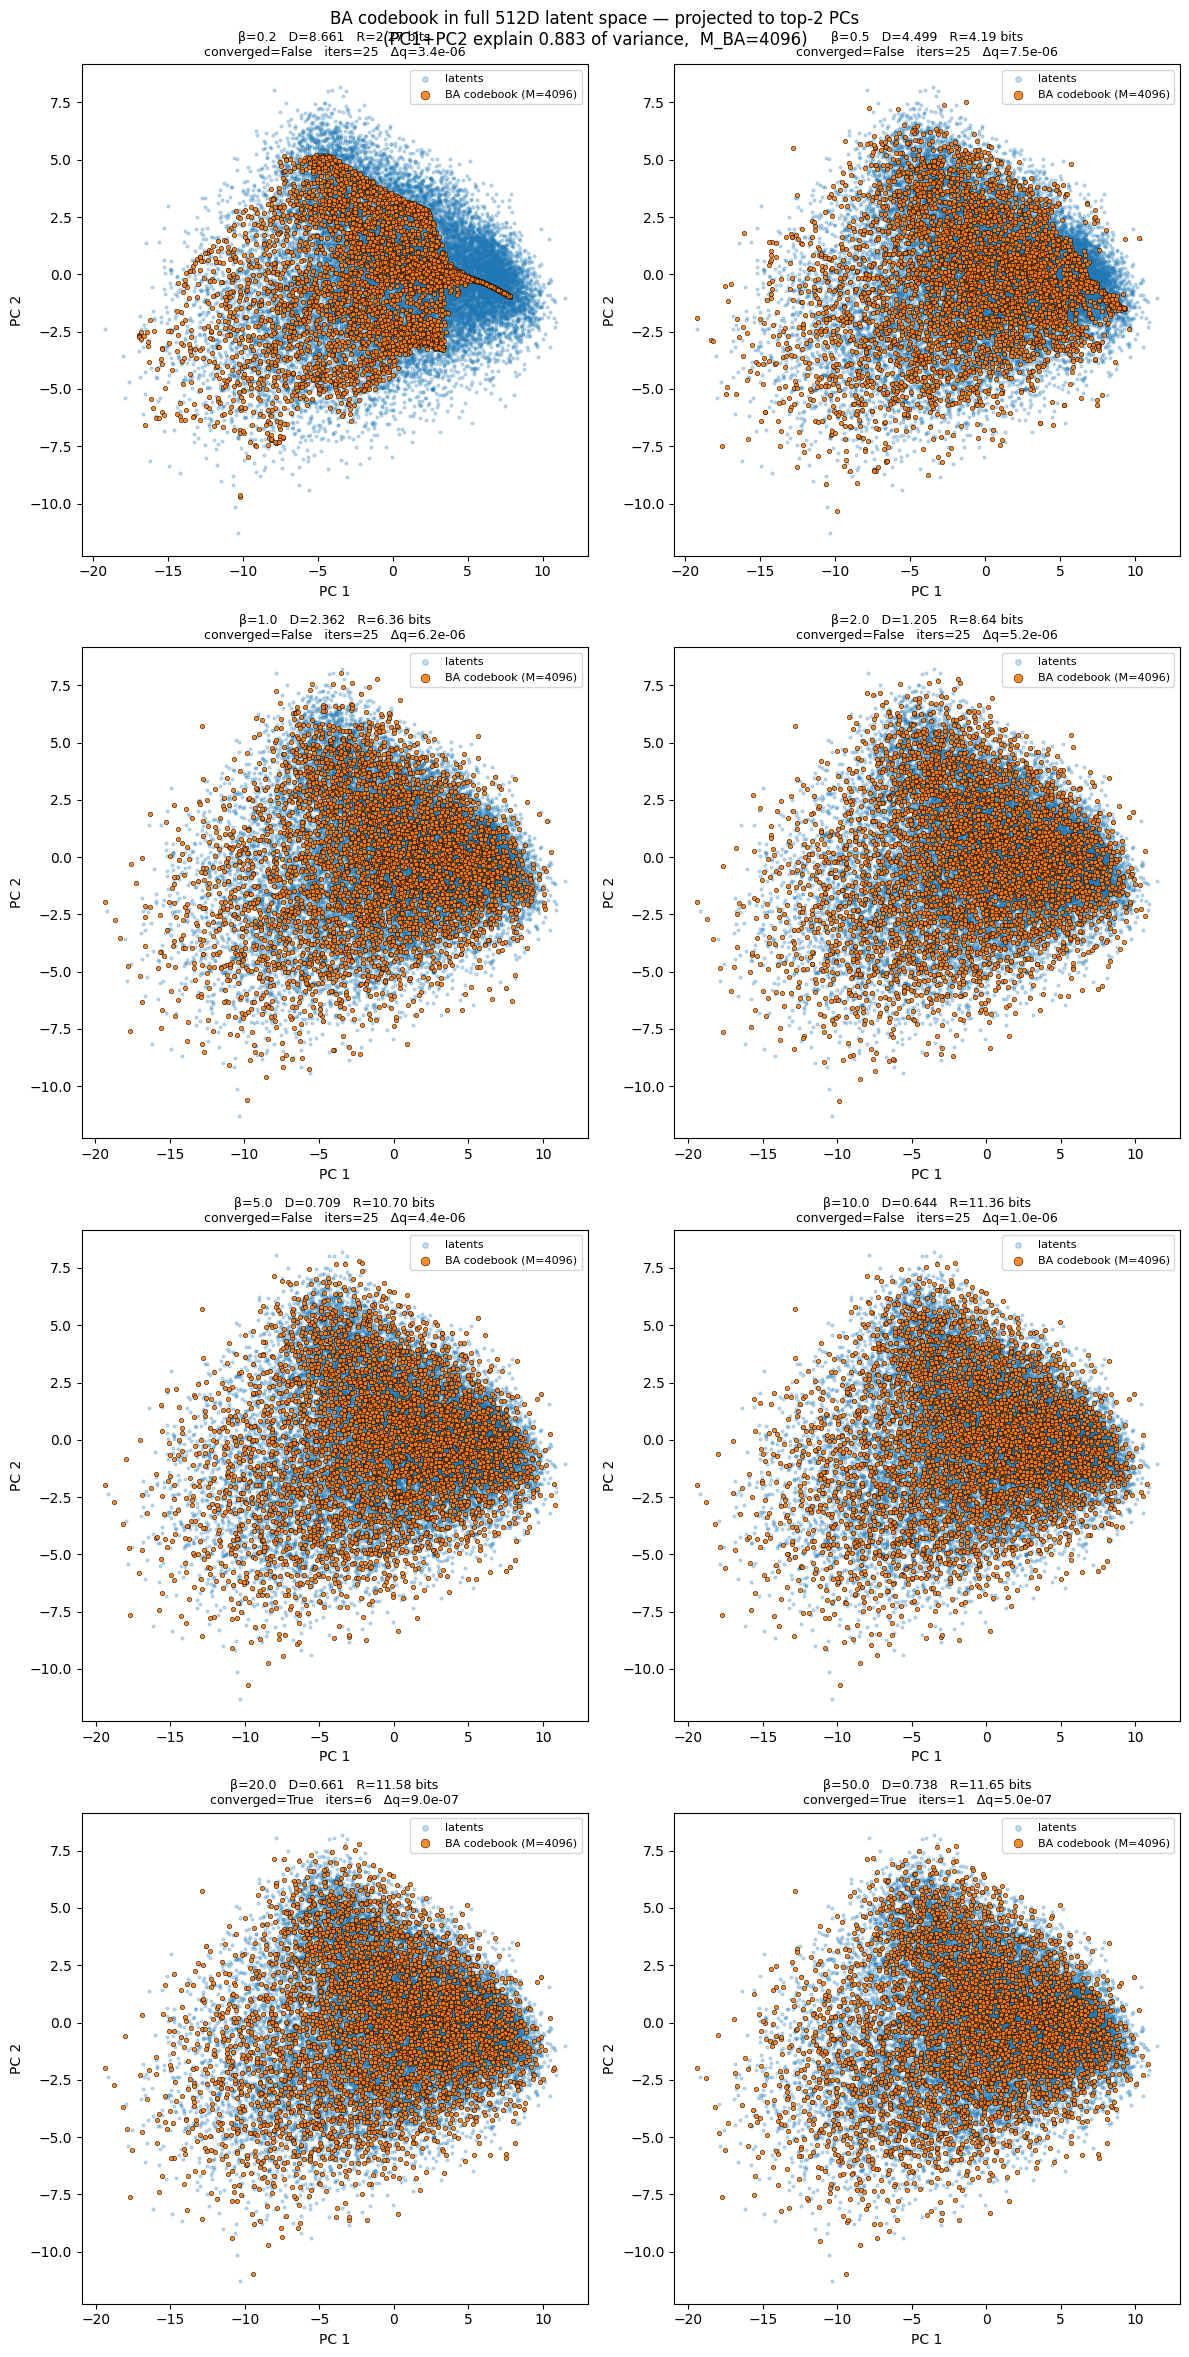

In [7]:
# Cell 6: 2x2 scatter plot — latents + BA codebook projected onto top-2 PCs
n_rows = math.ceil(len(results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for ax, r in zip(axes.flat, results):
    ax.scatter(
        U_pca2[:, 0], U_pca2[:, 1],
        c="tab:blue", s=4, alpha=0.25, label="latents", rasterized=True,
    )
    ax.scatter(
        r["Y_pca2"][:, 0], r["Y_pca2"][:, 1],
        c="tab:orange", s=10, alpha=0.9, edgecolors="k", linewidths=0.4,
        label=f"BA codebook (M={M_BA})", zorder=5,
    )
    ax.set_title(
        f"\u03b2={r['beta']}   D={r['D']:.3f}   R={r['R_bits']:.2f} bits\n"
        f"converged={r['converged']}   iters={r['n_outer_iters']}   "
        f"\u0394q={r['final_delta']:.1e}",
        fontsize=9,
    )
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle(
    f"BA codebook in full {D}D latent space — projected to top-2 PCs\n"
    f"(PC1+PC2 explain {var_explained:.3f} of variance,  M_BA={M_BA})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

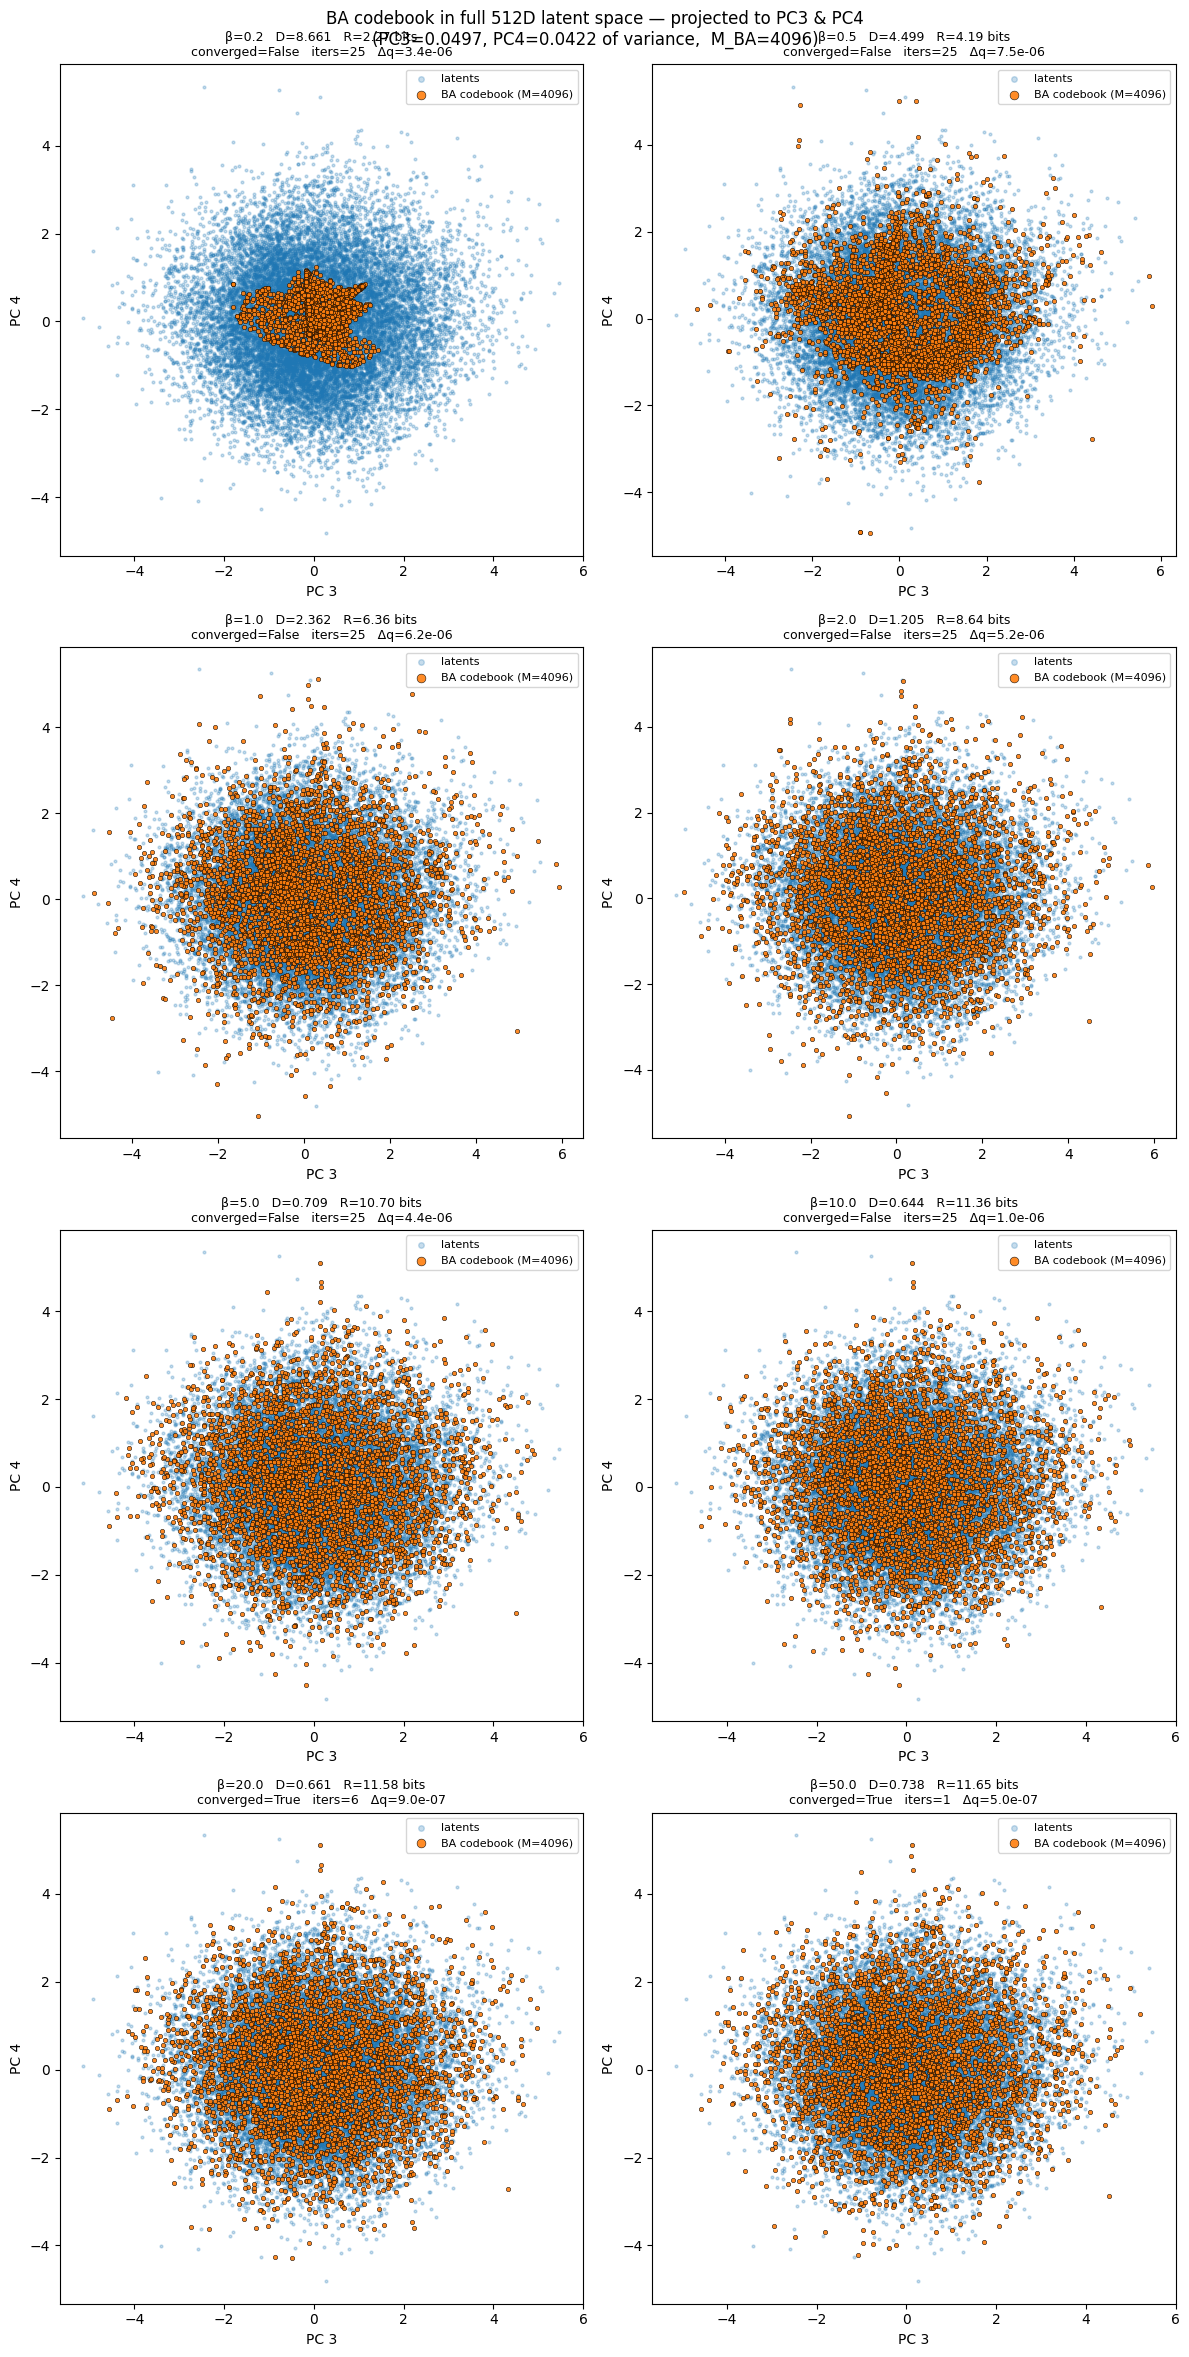

In [8]:
# Cell 7: Same scatter grid projected onto PC3 and PC4
n_rows = math.ceil(len(results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for ax, r in zip(axes.flat, results):
    ax.scatter(
        U_pca34[:, 0], U_pca34[:, 1],
        c="tab:blue", s=4, alpha=0.25, label="latents", rasterized=True,
    )
    ax.scatter(
        r["Y_pca34"][:, 0], r["Y_pca34"][:, 1],
        c="tab:orange", s=10, alpha=0.9, edgecolors="k", linewidths=0.4,
        label=f"BA codebook (M={M_BA})", zorder=5,
    )
    ax.set_title(
        f"\u03b2={r['beta']}   D={r['D']:.3f}   R={r['R_bits']:.2f} bits\n"
        f"converged={r['converged']}   iters={r['n_outer_iters']}   "
        f"\u0394q={r['final_delta']:.1e}",
        fontsize=9,
    )
    ax.set_xlabel("PC 3")
    ax.set_ylabel("PC 4")
    ax.legend(fontsize=8, markerscale=2)

evr = pca6.explained_variance_ratio_
fig.suptitle(
    f"BA codebook in full {D}D latent space — projected to PC3 & PC4\n"
    f"(PC3={evr[2]:.4f}, PC4={evr[3]:.4f} of variance,  M_BA={M_BA})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

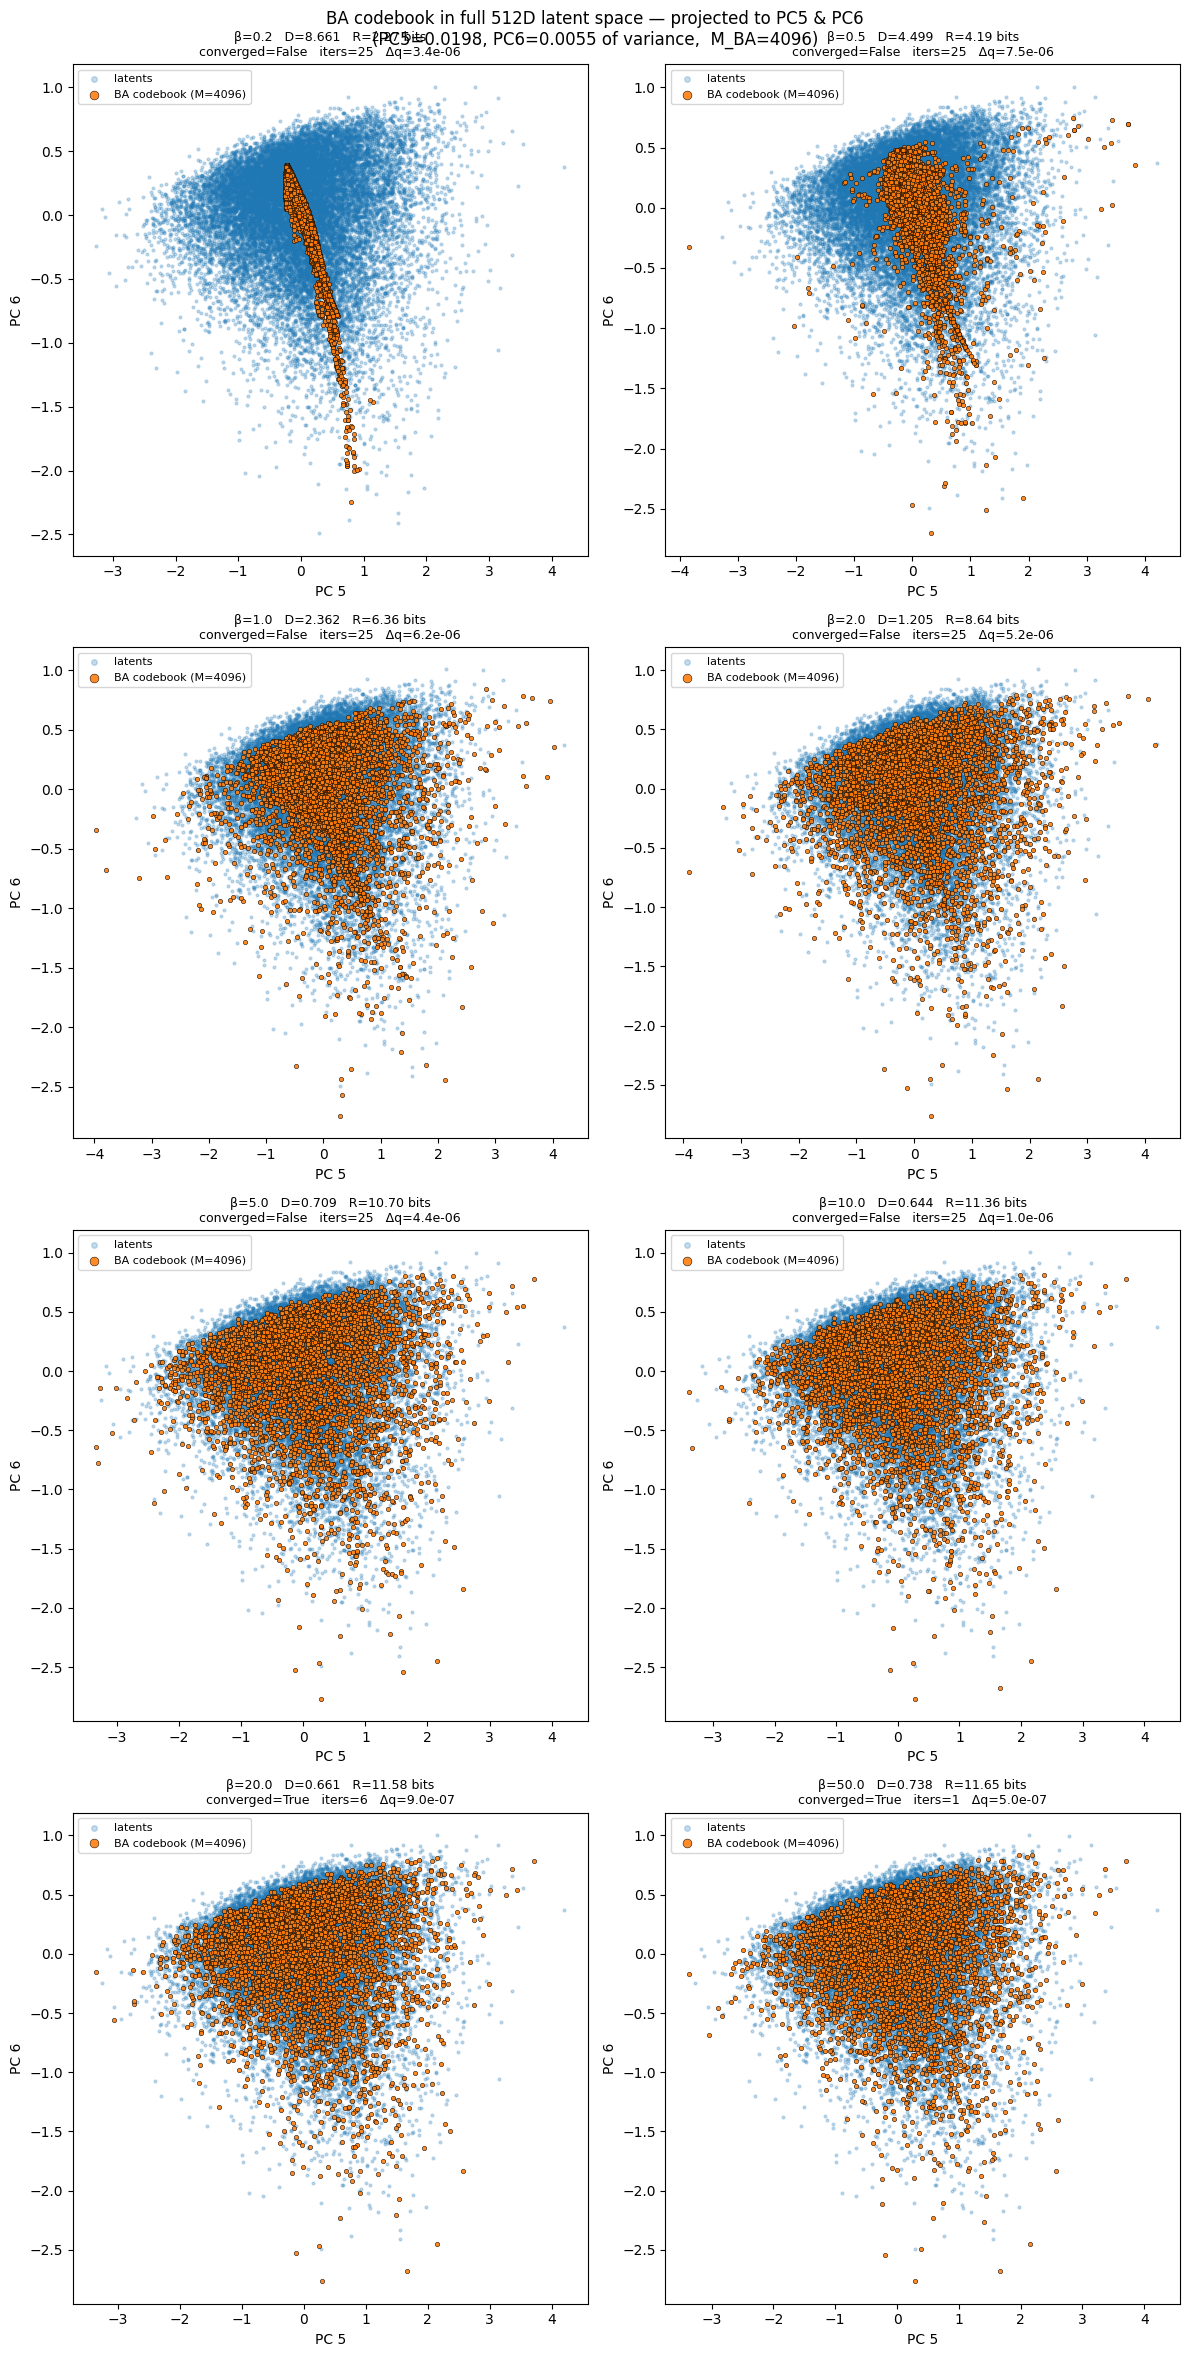

In [9]:
# Cell 8: Same scatter grid projected onto PC5 and PC6
n_rows = math.ceil(len(results) / 2)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for ax, r in zip(axes.flat, results):
    ax.scatter(
        U_pca56[:, 0], U_pca56[:, 1],
        c="tab:blue", s=4, alpha=0.25, label="latents", rasterized=True,
    )
    ax.scatter(
        r["Y_pca56"][:, 0], r["Y_pca56"][:, 1],
        c="tab:orange", s=10, alpha=0.9, edgecolors="k", linewidths=0.4,
        label=f"BA codebook (M={M_BA})", zorder=5,
    )
    ax.set_title(
        f"\u03b2={r['beta']}   D={r['D']:.3f}   R={r['R_bits']:.2f} bits\n"
        f"converged={r['converged']}   iters={r['n_outer_iters']}   "
        f"\u0394q={r['final_delta']:.1e}",
        fontsize=9,
    )
    ax.set_xlabel("PC 5")
    ax.set_ylabel("PC 6")
    ax.legend(fontsize=8, markerscale=2)

evr = pca6.explained_variance_ratio_
fig.suptitle(
    f"BA codebook in full {D}D latent space — projected to PC5 & PC6\n"
    f"(PC5={evr[4]:.4f}, PC6={evr[5]:.4f} of variance,  M_BA={M_BA})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

 beta        D    R_bits  converged  n_outer_iters  final_delta  elapsed_s
  0.2 8.661079  2.269219      False             25 3.406603e-06  31.920073
  0.5 4.498686  4.194746      False             25 7.495284e-06  31.825432
  1.0 2.361692  6.357663      False             25 6.189104e-06  31.875995
  2.0 1.205142  8.644925      False             25 5.151727e-06  31.743583
  5.0 0.708771 10.702575      False             25 4.407251e-06  31.844756
 10.0 0.643738 11.357772      False             25 1.032371e-06  31.845609
 20.0 0.661238 11.575608       True              6 9.031501e-07   7.831461
 50.0 0.737814 11.651359       True              1 5.003531e-07   1.513069


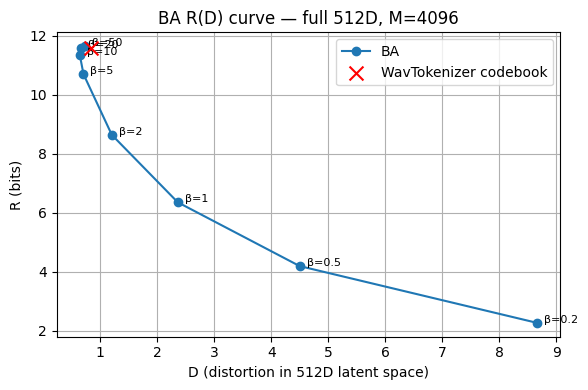

In [11]:
# Cell 7: R(D) curve + summary table
df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("Y_pca2", "Y_pca34", "Y_pca56")}
    for r in results
])
print(df.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(df["D"], df["R_bits"], marker="o", label="BA")
for _, row in df.iterrows():
    plt.text(row["D"], row["R_bits"], f"  \u03b2={row['beta']:g}", fontsize=8)
plt.scatter([D_wt], [H_wt], marker="x", color="red", s=100, zorder=5,
            label="WavTokenizer codebook")
plt.xlabel(f"D (distortion in {D}D latent space)")
plt.ylabel("R (bits)")
plt.title(f"BA R(D) curve — full {D}D, M={M_BA}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()